### Import libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [2]:
import numpy as np

### Load zip file

In [ ]:
zip_path = "pneumonia_detection.zip"

import zipfile

with zipfile.ZipFile(zip_path, "r") as file:
  file.extractall()

In [ ]:
import os

file_path = 'pneumonia_detection.zip'

# Check if the file exists and its size
if os.path.exists(file_path):
    print(f"File exists. Size: {os.path.getsize(file_path)} bytes")
    # Use the 'file' command to determine the file type
    !file {file_path}
else:
    print("File does not exist at the specified path.")

File exists. Size: 1226164809 bytes
/content/pneumonia_detection.zip: Zip archive data, at least v2.0 to extract, compression method=store


### Extract data from folders

In [3]:
train_dataset_path = "pneumonia_detection/train"

train_img_path = []
train_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(train_dataset_path, class_name)

  for file in os.listdir(class_dir):
    train_img_path.append(os.path.join(class_dir, file))
    train_labels.append(label)

In [4]:
val_dataset_path = "pneumonia_detection/val"

val_img_path = []
val_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(val_dataset_path, class_name)

  for file in os.listdir(class_dir):
    val_img_path.append(os.path.join(class_dir, file))
    val_labels.append(label)

In [5]:
test_dataset_path = "pneumonia_detection/test"

test_img_path = []
test_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(test_dataset_path, class_name)

  for file in os.listdir(class_dir):
    test_img_path.append(os.path.join(class_dir, file))
    test_labels.append(label)

### Analyse the train data - class imbalance, etc

In [6]:
count = np.bincount(train_labels)
print(f"Class distribution in training data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(val_labels)
print(f"Class distribution in validation data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(test_labels)
print(f"Class distribution in test data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

Class distribution in training data:
Class NORMAL: 1236
Class PNEUMONIA: 3770
Class distribution in validation data:
Class NORMAL: 113
Class PNEUMONIA: 113
Class distribution in test data:
Class NORMAL: 234
Class PNEUMONIA: 390


### Creating dataset pipeline for train, test and validation datasets

In [7]:
train_data = tf.data.Dataset.from_tensor_slices((train_img_path, train_labels))
val_data = tf.data.Dataset.from_tensor_slices((val_img_path,val_labels))
test_data = tf.data.Dataset.from_tensor_slices((test_img_path, test_labels))

In [8]:
def preprocessing(path, label):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, ((224,224)))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  label = tf.expand_dims(label, axis=-1) # Reshape label to (batch_size, 1)
  return image, label

In [9]:
train_data = train_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(len(train_labels))
train_data = train_data.batch(32)
train_data = train_data.prefetch(tf.data.AUTOTUNE)

val_data = val_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_data.batch(32)
val_data = val_data.prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.batch(32)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

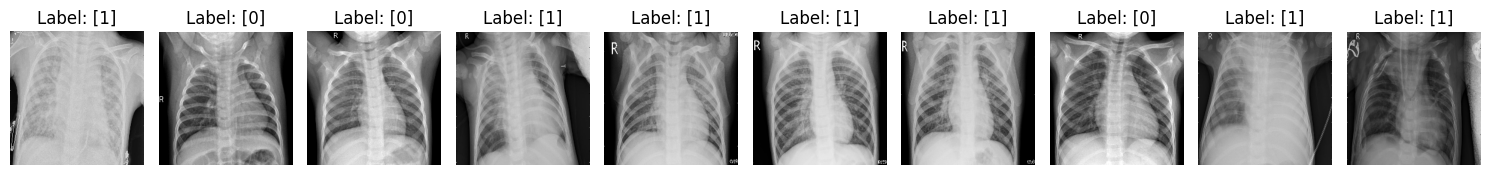

In [10]:
for images, labels in train_data.take(1):
  plt.figure(figsize=(15, 10))
  for i in range(10):
    display_image = (images[i] + 1)/2
    plt.subplot(1, 10, i + 1)
    plt.imshow(display_image)
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

### Building the classification model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, GlobalAveragePooling2D, MaxPooling2D, Dropout, Dense

model = Sequential([
    Conv2D(32, (3,3),padding="same", activation="relu", input_shape = (224,224,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPooling2D(),
    Conv2D(128,(3,3), padding="same", activation="relu"),
    MaxPooling2D(),
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# import keras-cv for focal loss
import keras_cv

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=keras_cv.losses.FocalLoss(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.05,
    patience = 3,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 20,
    callbacks = early_stopping
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 847ms/step - accuracy: 0.7245 - loss: 0.0484 - pr_auc: 0.9372 - precision: 0.9024 - recall: 0.7111 - roc_auc: 0.8336 - val_accuracy: 0.8761 - val_loss: 0.0335 - val_pr_auc: 0.9497 - val_precision: 0.9381 - val_recall: 0.8053 - val_roc_auc: 0.9317
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 855ms/step - accuracy: 0.8606 - loss: 0.0315 - pr_auc: 0.9774 - precision: 0.9666 - recall: 0.8440 - roc_auc: 0.9326 - val_accuracy: 0.8761 - val_loss: 0.0478 - val_pr_auc: 0.9365 - val_precision: 0.8761 - val_recall: 0.8761 - val_roc_auc: 0.9318
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 145s 875ms/step - accuracy: 0.8600 - loss: 0.0306 - pr_auc: 0.9791 - precision: 0.9663 - recall: 0.8435 - roc_auc: 0.9367 - val_accuracy: 0.9159 - val_loss: 0.0361 - val_pr_auc: 0.9549 - val_precision: 0.9519 - val_recall: 0.8761 - val_roc_auc: 0.9411
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 797ms/step - accuracy: 0.8917 - loss: 0.0255 - pr_auc: 0.9852 - precision: 0.97

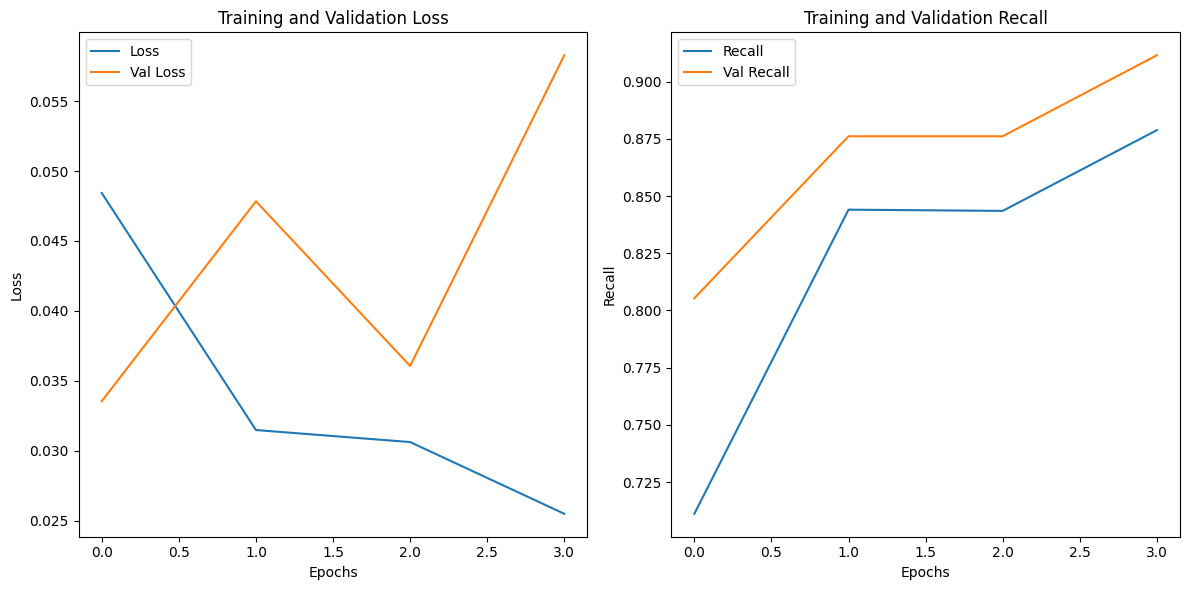

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # Subplot for Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Loss", "Val Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2) # Subplot for Recall
plt.plot(history.history["recall"])
plt.plot(history.history["val_recall"])
plt.legend(["Recall", "Val Recall"])
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("Training and Validation Recall")

plt.tight_layout()
plt.show()

### Evaluating the model on the test set

In [18]:
results = model.evaluate(test_data, return_dict = True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7949 - loss: 0.0531 - pr_auc: 0.9248 - precision: 0.8680 - recall: 0.7923 - roc_auc: 0.8757


In [19]:
results

{'accuracy': 0.7948718070983887,
 'loss': 0.05305401608347893,
 'pr_auc': 0.9248170256614685,
 'precision': 0.867977499961853,
 'recall': 0.7923076748847961,
 'roc_auc': 0.8756957650184631}

In [20]:
print(f"Results")
print(f"Loss:{results["loss"]:.2f}")
print(f"Accuracy:{results["accuracy"]:.2f}")
print(f"Precision:{results["precision"]:.2f}")
print(f"Recall:{results["recall"]:.2f}")
print(f"AUC-ROC:{results["roc_auc"]:.2f}")
print(f"PR-AUC:{results["pr_auc"]:.2f}")

Results
Loss:0.05
Accuracy:0.79
Precision:0.87
Recall:0.79
AUC-ROC:0.88
PR-AUC:0.92


### Confusion matrix

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

y_preds = model.predict(test_data)

y_preds = (y_preds > 0.5).astype(int).flatten()

# for y_true

y_true = []

for image,label in test_data:
  y_true.extend(label.numpy())

y_true = np.array(y_true)

# Confusion matrix

cm = confusion_matrix(y_true, y_preds)
print(cm)

# Classification report

print(classification_report(y_true, y_preds))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
[[187  47]
 [ 81 309]]
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       234
           1       0.87      0.79      0.83       390

    accuracy                           0.79       624
   macro avg       0.78      0.80      0.79       624
weighted avg       0.80      0.79      0.80       624



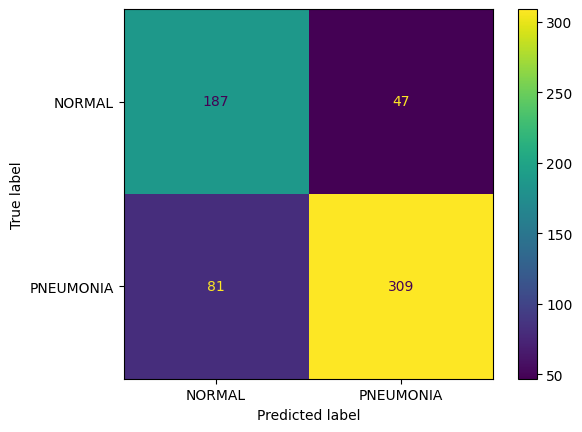

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay.from_predictions(y_true, y_preds, display_labels=["NORMAL", "PNEUMONIA"])
